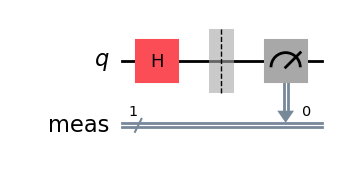

In [1]:
from qiskit import QuantumCircuit

qcoin = QuantumCircuit(1)
qcoin.h(0)
qcoin.measure_all()

qcoin.draw("mpl")

Qiskit RunTime

# Load the Qiskit Runtime service
from qiskit_ibm_runtime import QiskitRuntimeService

# Syntax for first saving your token.  Delete these lines after saving your credentials.
# QiskitRuntimeService.save_account(channel='ibm_quantum_platform', instance = '<YOUR_IBM_INSTANCE_CRN>', token='<YOUR-API_KEY>', overwrite=True, set_as_default=True)
# service = QiskitRuntimeService(channel='ibm_quantum_platform')

# Load saved credentials
service = QiskitRuntimeService()

# Load the Runtime primitive and session
from qiskit_ibm_runtime import (
    SamplerV2 as Sampler,
    EstimatorV2 as Estimator,
)

# Use the least busy backend
backend = service.least_busy()
print(backend.name)

In [ ]:
from qiskit_aer import AerSimulator
from qiskit.providers.fake_provider import GenericBackendV2 as GB
from qiskit.primitives import BackendSamplerV2 as BS, BackendEstimatorV2 as BE
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.visualization import plot_histogram

# 1. Spin up a local, mock hardware layout (e.g., a 7-qubit system)
# This provides the physical properties that 'target' and 'AerSimulator' need!
fake_hardware = GB(num_qubits=7)

# 2. Generate a local simulator that mimics this specific fake hardware's noise profile
backend_sim = AerSimulator.from_backend(fake_hardware)

# 3. Setup your modern V2 Primitives using the noisy local simulator engine
sampler_sim = BS(backend=backend_sim)
estimator_sim = BE(backend=backend_sim)
# Every job created by this sampler instance will run 500 times by default
#sampler_sim = BS(backend=backend_sim, options={"default_shots": 500})

## --- Transpilation Section ---
# 4. Extract the hardware target properties from our local mock architecture
target = fake_hardware.target

# 5. Build and execute the compilation pass manager
pm = generate_preset_pass_manager(target=target, optimization_level=3)

# 6. Transpile your original quantum circuit ('qcoin') into an Instruction Set Architecture (ISA) circuit
# (Make sure the cell where you built 'qcoin' has been executed first!)
qc_isa = pm.run(qcoin)

print("Setup successful! Local noisy simulator engine ready and circuit transpiled.")
#--------------1----------
job = sampler_sim.run([qc_isa])
#job = sampler_sim.run([qc_isa], shots=200)
counts=job.result()[0].data.meas.get_counts()



plot_histogram(counts)

# On real hardware:
sampler = Sampler(mode=backend)
pubs = [qc_isa]
job = sampler.run(pubs, shots=1000)
res = job.result()

counts = res[0].data.meas.get_counts()

In [13]:
from qiskit.quantum_info import Pauli

qcoin = QuantumCircuit(1)
qcoin.h(0)

# for Estimator, we do not apply the measurement to the circuit

## Transpile
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend_sim.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)

obs = Pauli("Z")

qc_isa = pm.run(qcoin)
obs_isa = obs.apply_layout(layout=qc_isa.layout)

#--------------
job = estimator_sim.run([[qc_isa, obs_isa]])
res=job.result()

print(res[0].data.evs)

0.00390625


# On real hardware:
estimator = Estimator(mode=backend)
pubs = [(qc_isa, obs_isa)]
job = estimator.run([[qc_isa, obs_isa]])
res = job.result()

In [16]:
# Step 1: map problem

qcoin_lr = QuantumCircuit(1)
qcoin_lr.h(0)

obs = Pauli("X")


# Step 2: Transpile the circuit

pm = generate_preset_pass_manager(target=target, optimization_level=3)
qc_isa = pm.run(qcoin_lr)
obs_isa = obs.apply_layout(layout=qc_isa.layout)

# Step 3: Run the circuit on a real quantum computer

# estimator = Estimator(mode=backend)
# pubs = [(qc_isa, obs_isa)]
# job = estimator.run([[qc_isa, obs_isa]])
# res = job.result()

# Run the job on the Aer simulator with noise model from real backend
job = estimator_sim.run([[qc_isa,obs_isa]])
res=job.result()

# Step 4: Return the result in classical form, and analyze.

print(res[0].data.evs)

0.9912109375


To create a ∣−⟩ state, you need to apply a Pauli-X (NOT) gate to flip the qubit to ∣1⟩, and then apply the Hadamard (H) gate to split it into a negative superposition.

In [18]:
# Step 1: map problem
qcoin_lr = QuantumCircuit(1)
qcoin_lr.x(0)  # 1. Flip from |0> to |1>
qcoin_lr.h(0)  # 2. Put into superposition to create the |-> state

obs = Pauli("X")


# Step 2: Transpile the circuit

pm = generate_preset_pass_manager(target=target, optimization_level=3)
qc_isa = pm.run(qcoin_lr)
obs_isa = obs.apply_layout(layout=qc_isa.layout)

# Step 3: Run the circuit on a real quantum computer

# estimator = Estimator(mode=backend)
# pubs = [(qc_isa, obs_isa)]
# job = estimator.run([[qc_isa, obs_isa]])
# res = job.result()

# Run the job on the Aer simulator with noise model from real backend
job = estimator_sim.run([(qc_isa,obs_isa)])
res=job.result()

# Step 4: Return the result in classical form, and analyze.

print(res[0].data.evs)

-0.994140625


To see how the phase can cause interference in our quantum coin, let’s try to apply the Hadamard two times instead of just once. Classically, this wouldn’t make any sense – if applying the Hadamard is equivalent to flipping a coin, then you can’t flip a coin that is already flipping. But let's see what happens to the quantum coin:

In [ ]:
import numpy as np
qcoin_0 = QuantumCircuit(1)
qcoin_0.h(0)
qcoin_0.p(np.pi, 0)
qcoin_0.h(0)
qcoin_0.measure_all()

## Transpile

target = backend_sim.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)

qc_isa = pm.run(qcoin_0)

## Execute

# On real hardware:
# sampler = Sampler(mode=backend)
# pubs = [qc_isa]
# job = sampler.run(pubs, shots=1000)
# res = job.result()

# counts = res[0].data.meas.get_counts()


# or with Aer simulator with noise model from real backend
job = sampler_sim.run([qc_isa])
counts=job.result()[0].data.meas.get_counts()

## Analyze
plot_histogram(counts)

Edit the code cell below to change the phase such that the second Hadamard creates a superposition state with probabilities of 25% and 75% of finding the state in 
∣0⟩ and∣1⟩, respectively. Verify your answer with math.

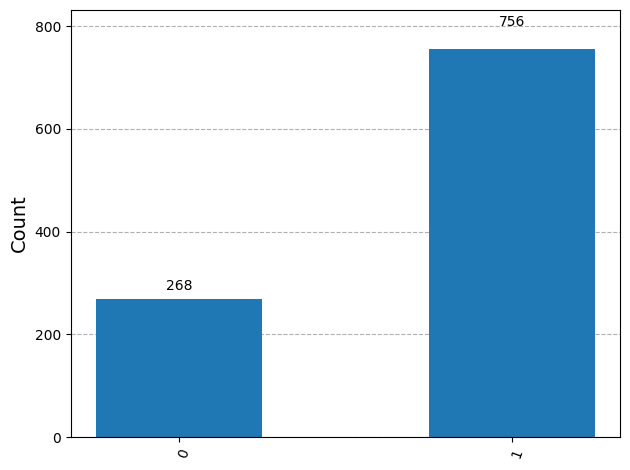

In [41]:
qcoin_phase = QuantumCircuit(1)
qcoin_phase.h(0)
qcoin_phase.rz(2*np.pi/3, 0)
qcoin_phase.h(0)
qcoin_phase.measure_all()


## Transpile

target = backend_sim.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)

qc_isa = pm.run(qcoin_phase)


# On real hardware:
# sampler = Sampler(mode=backend)
# pubs = [qc_isa]
# job = sampler.run(pubs, shots=1000)
# res = job.result()

# counts = res[0].data.meas.get_counts()



job = sampler_sim.run([qc_isa])
counts=job.result()[0].data.meas.get_counts()


plot_histogram(counts)

Say we want to construct an operation that, if applied twice, would be equivalent to the NOT gate. That is, we want a "squareroot of NOT," or NOT. We can do this by considering how the NOT gate is physically implemented on the coin: it's just a rotation of 180 degrees around, for example, the x-axis. So, if we were to rotate the coin just 90 degrees around the x-axis, it would be equivalent to a NOT gate.

So, while the x and z measurements yielded random results, the y measurement will alway yield the same result! If you recall the "quantum coin flip" experiment from the previous section, this is reminiscent to how the quantum coin behaved. It was measured to be 0 or 1 with 50/50 probability in the z-direction, but always ∣+⟩ and never ∣−⟩ along X. This is suggestive that perhaps a coin sitting still, on its edge, is a better way to visualize a superposition state of a qubit than coin wildly flipping through the air.

Let's use Qiskit to see if our "quantum coin" behaves the same way as our classical coin when a NOT gate is applied. We'll apply NOT to a qubit starting in ∣0⟩, then use Estimator to check the expectation value of the three observables, X, Y, and Z.



In [42]:
qcoin_a = QuantumCircuit(1)
qcoin_a.sx(0)

qcoin_a.draw("mpl")

obs1 = Pauli("X")
obs2 = Pauli("Y")
obs3 = Pauli("Z")


# Step 2: Transpile the circuit

pm = generate_preset_pass_manager(target=target, optimization_level=3)
qc_isa = pm.run(qcoin_a)
obs1_isa = obs1.apply_layout(layout=qc_isa.layout)
obs2_isa = obs2.apply_layout(layout=qc_isa.layout)
obs3_isa = obs3.apply_layout(layout=qc_isa.layout)


# Step 3: Run the circuit on a real quantum computer

# estimator = Estimator(mode=backend)
# pubs = [(qc_isa, [[obs1_isa], [obs2_isa], [obs3_isa]])]
# job = estimator.run(pubs)
# res = job.result()

# Run the job on the Aer simulator with noise model from real backend
pubs = [(qc_isa, [[obs1_isa], [obs2_isa], [obs3_isa]])]
job = estimator_sim.run(pubs)
res=job.result()


print(res[0].data.evs)

[[ 0.01660156]
 [-0.99121094]
 [ 0.02197266]]


The expectation values are 0, -1, and 0 for X, Y and Z, respectively.

NOT: 180 degrees around the x-axis

S.root of NOT 90 degrees around the x-axis

PHASE: rotation of ϕ around z-axis

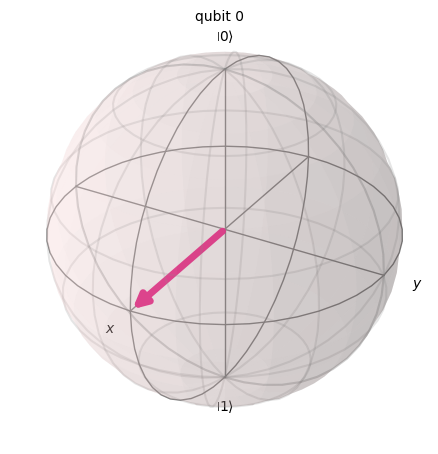

In [65]:
from qiskit.visualization import plot_bloch_multivector

qnot = QuantumCircuit(1)
#qnot.x(0)
#qnot.sx(0)
qnot.h(0)

plot_bloch_multivector(qnot)